In [1]:
import numpy as np
import PIL.Image as image
import matplotlib.pyplot as plt

load and show original image

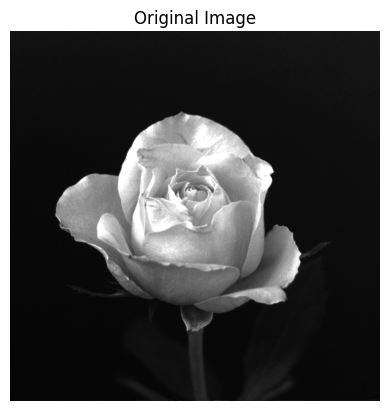

In [2]:
img = image.open('images/rose.tif').convert('L')
img_array = np.array(img)

plt.imshow(img_array, cmap='gray')
plt.title("Original Image")
plt.axis('off')
plt.show()

histogram (frequency)

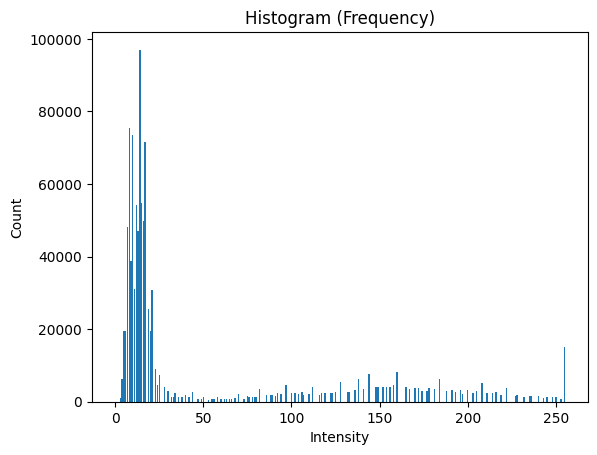

In [3]:
hist = np.zeros(256, dtype=int)

pixels = img_array.flatten()

for i in pixels:
    hist[i] += 1

plt.bar(range(256), hist)
plt.title("Histogram (Frequency)")
plt.xlabel("Intensity")
plt.ylabel("Count")
plt.show()

PDF

In [4]:
total_pixels = img_array.size

pdf = np.zeros(256, dtype=float)

for i in range(256):
    pdf[i] = hist[i]/total_pixels

CDF

In [5]:
cdf = np.zeros(256, dtype=float)
cdf[0] = pdf[0]

for i in range(1, 256):
    cdf[i] = cdf[i-1] + pdf[i]

New Gray Levels (mapping)

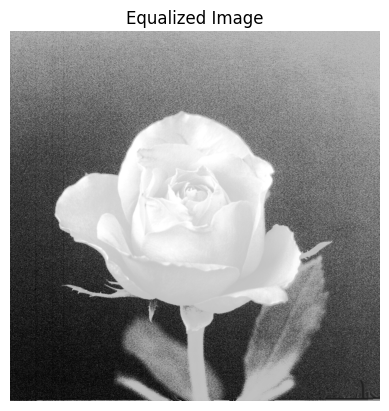

In [6]:
new_level = np.zeros(256, dtype=int)
new_level = np.round(255 * cdf) 


equalized_img = np.zeros_like(img_array)

H, W = img_array.shape

for i in range(H):
    for j in range(W):
        equalized_img[i, j] = new_level[img_array[i, j]]

plt.imshow(equalized_img, cmap='gray')
plt.title("Equalized Image")
plt.axis('off')
plt.show()

histogram after equalization

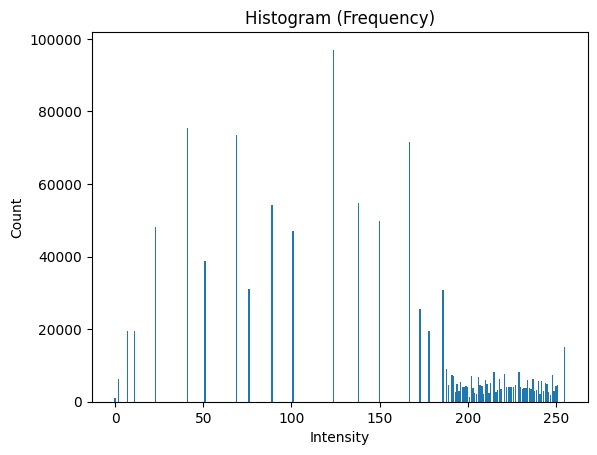

In [7]:
hist = np.zeros(256, dtype=int)
pixels = equalized_img.flatten()

for i in pixels:
    hist[i] += 1

plt.bar(range(256), hist)
plt.title("Histogram (Frequency)")
plt.xlabel("Intensity")
plt.ylabel("Count")
plt.show()